In [39]:
# Importing Required Libraries..

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Loading the dataset
df = pd.read_csv("dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [41]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

This dataset contains all the information about restaurants.

In [42]:
# Handling the missing values with fillna()..

numerical_column = df.select_dtypes(include=['int64', 'float64']).columns
categorical_column = df.select_dtypes(include=['object']).columns

for column in numerical_column:
    df[column].fillna(df[column].median())

for column in categorical_column:
    df[column].fillna(df[column].mode()[0])

In [43]:
# Encode the categoriacal variables..

encoder = LabelEncoder()

for column in categorical_column:
    df[column] = encoder.fit_transform(df[column])

In [44]:
# Droping of non-informative columns if present and defining features and target

drop_column = ['Restaurant Name', 'Address', 'Restaurant ID']

for column in drop_column:
    if column in df.columns:
        df.drop(column, axis=1, inplace=True)

X = df.drop('Aggregate rating', axis=1)
y = df['Aggregate rating']

In [45]:
# Training the model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LinearRegression()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

print(f"Linear Regression MAE: ", round(mae, 2))
print(f"MSE: ", round(mse, 2))
print(f"RMSE: ", round(rmse, 2))
print(f"Linear Regression R2 score: ", round(r2, 2))

Linear Regression MAE:  0.94
MSE:  1.27
RMSE:  1.13
Linear Regression R2 score:  0.44


The dataset is split into tarining and testing sets to evaluate the model on unseen data.

In [56]:
model2 = DecisionTreeRegressor(random_state = 42)
model2.fit(X_train, y_train)

y_predict2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, y_predict2)
mse2 = mean_squared_error(y_test, y_predict2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y_test, y_predict2)

print(f"Decision Tree MAE: ", round(mae2, 2))
print(f"MSE: ", round(mse2, 2))
print(f"RMSE: ", round(rmse2, 2))
print(f"Decision Tree R2 score: ", round(r2_2, 2))

Decision Tree MAE:  0.15
MSE:  0.06
RMSE:  0.24
Decision Tree R2 score:  0.97


In [34]:
model_coefficient = pd.Series(
    model.coef_,
    index = X.columns
).sort_values(ascending = False)

model_coefficient.head(10)

Has Online delivery     6.741964e-01
Price range             5.433588e-01
Country Code            6.417218e-03
Longitude               1.912241e-03
Votes                   6.264115e-04
Latitude                3.288565e-04
Locality                1.439584e-04
Average Cost for two    9.214253e-07
Switch to order menu    8.881784e-16
Cuisines               -1.901335e-04
dtype: float64

In [59]:
model2_importance = pd.Series(
    model2.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

model2_importance.head(10)

Votes                   0.899517
Rating color            0.081987
Rating text             0.007401
Latitude                0.002886
Longitude               0.002607
Cuisines                0.001763
Average Cost for two    0.001526
Locality Verbose        0.000701
Locality                0.000698
Has Online delivery     0.000350
dtype: float64

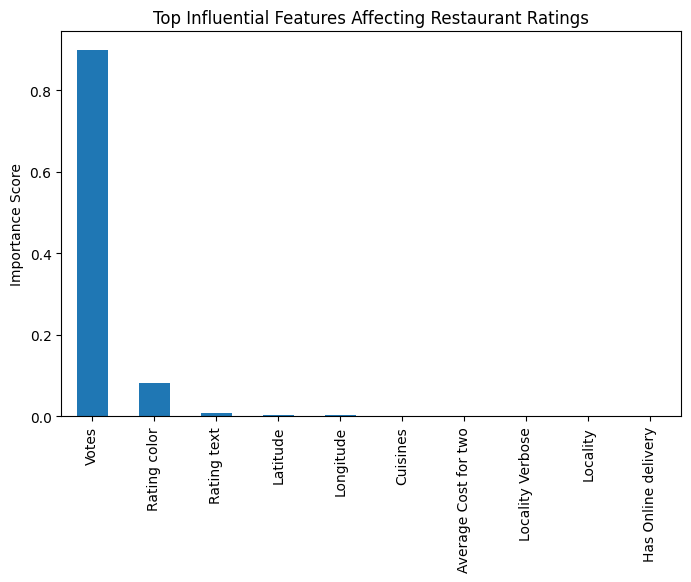

In [58]:
plt.figure(figsize=(8,5))
model2_importance.head(10).plot(kind='bar')
plt.title("Top Influential Features Affecting Restaurant Ratings")
plt.ylabel("Importance Score")
plt.show()

Features such as votes, price range, and service availability are observed to have a significant impact on restaurant ratings.

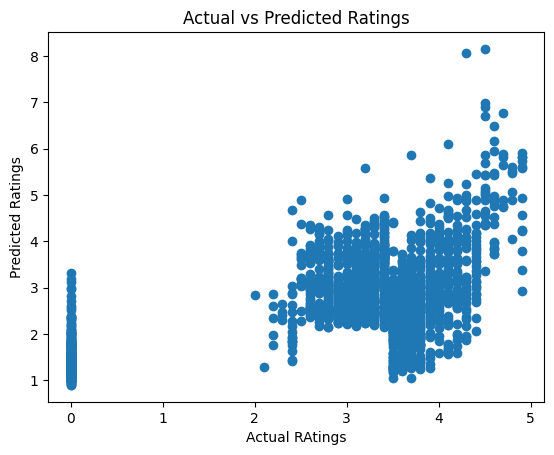

In [52]:
plt.scatter(y_test, y_predict)
plt.xlabel("Actual RAtings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

The scatter plot confirms that the model produces reliable predictions with reasonable accuracy.

In this task regression models are developed to predict restaurant ratings.